# Notebook 5 — Hierarchical Clustering

**DATA5322 — Statistical Machine Learning II**  
Seattle University, Spring 2026  
Team: Ruman Sidhu, Paul Skentzos, Hamda Hassan

---

> **Status:** Placeholder — to be completed after K-Means (Notebook 4).

## Planned Content
- Compute hierarchical clustering using complete, single, and average linkage
- Plot side-by-side dendrograms for each linkage method
- Cut dendrogram at k=4 and compare assignments to K-Means results (Adjusted Rand Index)
- Produce a clustered gene expression heatmap ordered by cluster assignment
- Discuss which linkage method produces the most interpretable subtype structure

---
## 1. Imports and Setup

We import the libraries needed for hierarchical clustering, dendrogram plotting, and comparison with the K-Means results from Notebook 4.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import adjusted_rand_score

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

DATA_DIR = Path('../data')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

print('Setup complete.')

Setup complete.


---
## 2. Load PCA-Reduced Data and K-Means Labels

We load the PCA-reduced matrix produced in Notebook 2 and the K-Means cluster labels produced in Notebook 4.

The PCA-reduced matrix contains 529 tumor samples represented by 24 principal components. These components summarize the strongest gene expression patterns while reducing noise from the original 5,000-gene matrix.

The K-Means labels are used later as a comparison point for the hierarchical clustering results.

In [4]:
X = np.load(DATA_DIR / 'X_pca_reduced.npy')

sample_ids = pd.read_csv(
    DATA_DIR / 'sample_ids.csv'
)['SampleID'].tolist()

kmeans_labels = pd.read_csv(
    DATA_DIR / 'kmeans_clusters.csv'
)['Cluster'].values

print(f'PCA matrix shape : {X.shape}')
print(f'Sample IDs       : {len(sample_ids)}')
print(f'K-Means labels   : {len(kmeans_labels)}')

PCA matrix shape : (529, 24)
Sample IDs       : 529
K-Means labels   : 529


---
## 3. Compute Hierarchical Clustering Linkages

Hierarchical clustering builds a tree structure (dendrogram) by progressively merging samples based on their similarity.

We evaluate three common linkage methods:

- Single linkage: merges clusters using the closest pair of points.
- Complete linkage: merges clusters using the farthest pair of points.
- Average linkage: merges clusters using the average distance between all pairs of points.

Comparing these methods allows us to determine which produces the clearest cluster structure in the PCA-reduced breast cancer data.

In [6]:
single_linkage = linkage(X, method='single')
complete_linkage = linkage(X, method='complete')
average_linkage = linkage(X, method='average')

print('Hierarchical clustering complete.')

print(f'Single linkage shape   : {single_linkage.shape}')
print(f'Complete linkage shape : {complete_linkage.shape}')
print(f'Average linkage shape  : {average_linkage.shape}')

Hierarchical clustering complete.
Single linkage shape   : (528, 4)
Complete linkage shape : (528, 4)
Average linkage shape  : (528, 4)


---
## 4. Visualize Dendrograms

Dendrograms visualize the hierarchical clustering process.

Each merge operation is represented as a branch. Lower merges indicate more similar samples, while higher merges indicate larger differences between groups.

Comparing dendrograms across linkage methods helps identify which method reveals the clearest cluster structure.

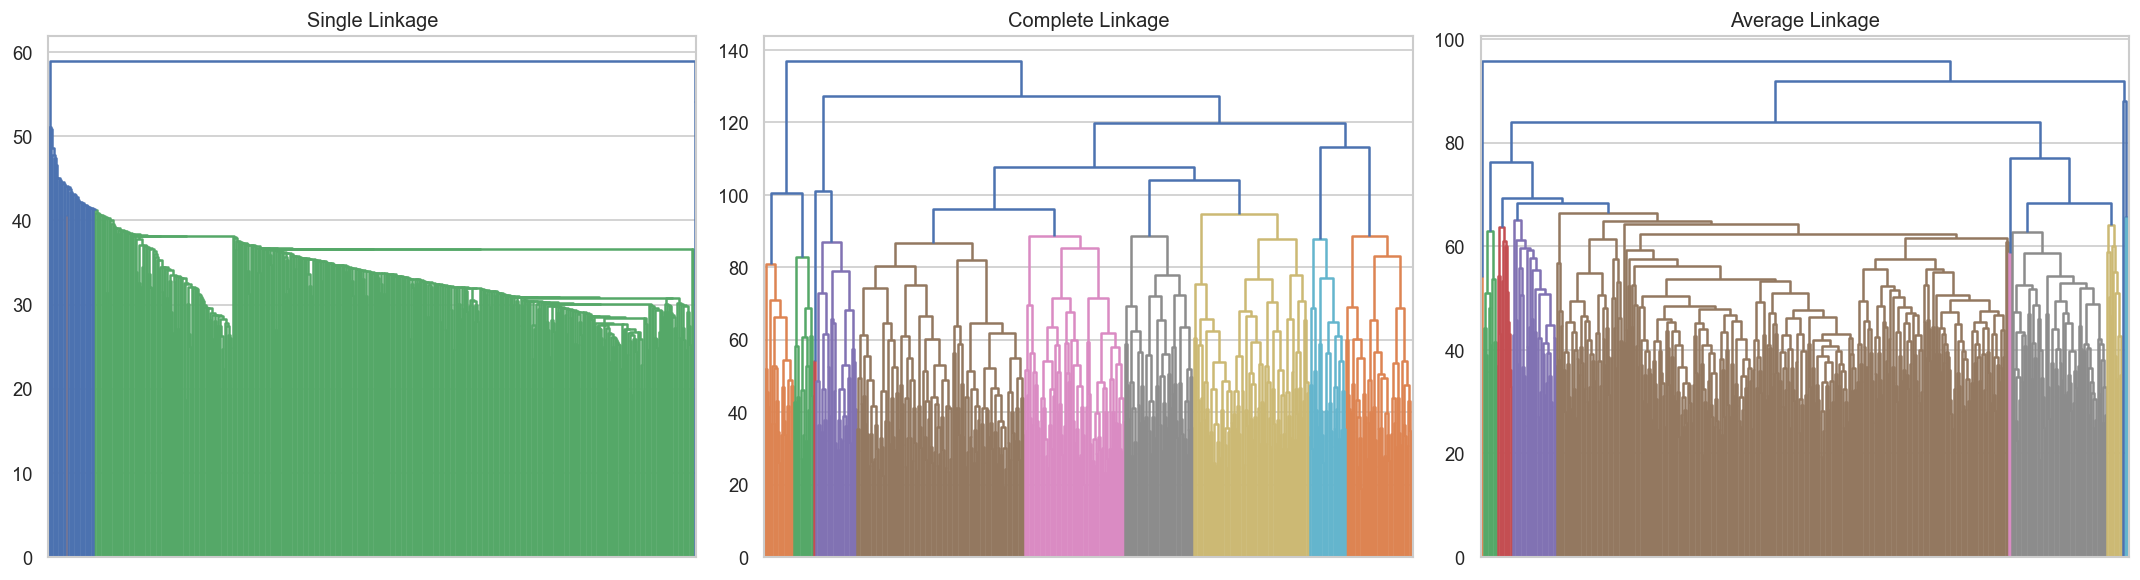

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dendrogram(
    single_linkage,
    no_labels=True,
    ax=axes[0]
)
axes[0].set_title('Single Linkage')

dendrogram(
    complete_linkage,
    no_labels=True,
    ax=axes[1]
)
axes[1].set_title('Complete Linkage')

dendrogram(
    average_linkage,
    no_labels=True,
    ax=axes[2]
)
axes[2].set_title('Average Linkage')

plt.tight_layout()
plt.show()

---
### Discussion: Comparing Linkage Methods

The dendrograms show substantial differences between linkage methods.

Single linkage exhibits the well-known chaining effect, where samples are connected through a sequence of nearest-neighbor relationships. This results in one large elongated cluster and makes interpretation difficult.

Complete linkage produces more compact and clearly separated groups. Large branches remain distinct until relatively high merge distances, suggesting stronger cluster separation.

Average linkage provides a balance between the two approaches. The resulting dendrogram shows several well-defined branches while remaining less sensitive to extreme observations than complete linkage.

Based on visual inspection, complete and average linkage appear to capture the underlying structure of the breast cancer samples more effectively than single linkage.

---
## 5. Cut Dendrograms at k=4

To compare hierarchical clustering with the K-Means solution from Notebook 4, we cut each dendrogram into four clusters.

A four-cluster solution is biologically motivated because breast cancer is commonly divided into four major molecular subtypes: Luminal A, Luminal B, HER2-enriched, and Triple-Negative.

In [10]:
single_labels = fcluster(
    single_linkage,
    t=4,
    criterion='maxclust'
)

complete_labels = fcluster(
    complete_linkage,
    t=4,
    criterion='maxclust'
)

average_labels = fcluster(
    average_linkage,
    t=4,
    criterion='maxclust'
)

print('Single linkage clusters:')
print(pd.Series(single_labels).value_counts().sort_index())

print('\nComplete linkage clusters:')
print(pd.Series(complete_labels).value_counts().sort_index())

print('\nAverage linkage clusters:')
print(pd.Series(average_labels).value_counts().sort_index())

Single linkage clusters:
1    526
2      1
3      1
4      1
Name: count, dtype: int64

Complete linkage clusters:
1     40
2     35
3    370
4     84
Name: count, dtype: int64

Average linkage clusters:
1      2
2    522
3      4
4      1
Name: count, dtype: int64


---
### Discussion: Cluster Sizes

The three linkage methods produced substantially different cluster assignments.

Single linkage resulted in one dominant cluster containing 526 samples and three singleton clusters. This behavior reflects the chaining effect commonly associated with single linkage and suggests poor separation of biologically meaningful groups.

Average linkage also produced a highly imbalanced solution, with 522 of the 529 samples assigned to a single cluster. This indicates that the method did not identify strong boundaries between major groups in the PCA-reduced data.

Complete linkage generated a more balanced partition consisting of clusters containing 40, 35, 370, and 84 samples. Although one cluster remains substantially larger than the others, all four groups contain meaningful numbers of samples and therefore provide a more interpretable clustering solution.

Based on cluster size distributions, complete linkage appears to produce the most useful clustering structure among the three methods.

---
## 6. Compare Hierarchical Clustering to K-Means

To quantify agreement between hierarchical clustering and K-Means, we compute the Adjusted Rand Index (ARI).

ARI ranges from:

- 1.0 = identical cluster assignments
- 0.0 = random agreement
- Negative values = worse than random agreement

Higher ARI values indicate stronger agreement between the clustering methods.

In [11]:
ari_single = adjusted_rand_score(
    kmeans_labels,
    single_labels
)

ari_complete = adjusted_rand_score(
    kmeans_labels,
    complete_labels
)

ari_average = adjusted_rand_score(
    kmeans_labels,
    average_labels
)

ari_results = pd.DataFrame({
    'Method': ['Single', 'Complete', 'Average'],
    'ARI': [ari_single, ari_complete, ari_average]
})

ari_results.sort_values(
    'ARI',
    ascending=False
)

,Method,ARI
1,Complete,0.1903
0,Single,0.0014
2,Average,-0.0007


---
### Discussion: Adjusted Rand Index Comparison

The Adjusted Rand Index (ARI) was used to measure agreement between the hierarchical clustering solutions and the K-Means clustering results from Notebook 4.

Complete linkage achieved the highest ARI value (0.1903), indicating the strongest agreement with the K-Means partition. Although the agreement is not particularly high, it is substantially better than the other linkage methods.

Single linkage produced an ARI near zero, reflecting its tendency to form one large chain-like cluster rather than meaningful groups. Average linkage performed similarly poorly and achieved a slightly negative ARI value.

These results support the visual evidence from the dendrograms and cluster size distributions. Among the methods evaluated, complete linkage appears to recover the most interpretable cluster structure in the PCA-reduced breast cancer dataset.

In [12]:
X_original = np.load(DATA_DIR / 'X_preprocessed.npy')

print(X_original.shape)

(529, 5000)


In [13]:
top_genes = pd.read_csv(DATA_DIR / 'top_genes.csv')

print(top_genes.head())
print()
print(top_genes.columns)
print()
print(top_genes.shape)

      Gene
0     AGR3
1    NPY1R
2    MUCL1
3    SYT13
4  CEACAM6

Index(['Gene'], dtype='object')

(5000, 1)


---
## 7. Clustered Gene Expression Heatmap

To visualize expression patterns across clusters, we create a heatmap using a subset of genes from the preprocessed expression matrix.

Displaying all 5,000 genes would be difficult to interpret, so we visualize the first 50 genes. Samples are ordered according to the complete-linkage cluster assignments because complete linkage produced the strongest agreement with the K-Means solution.

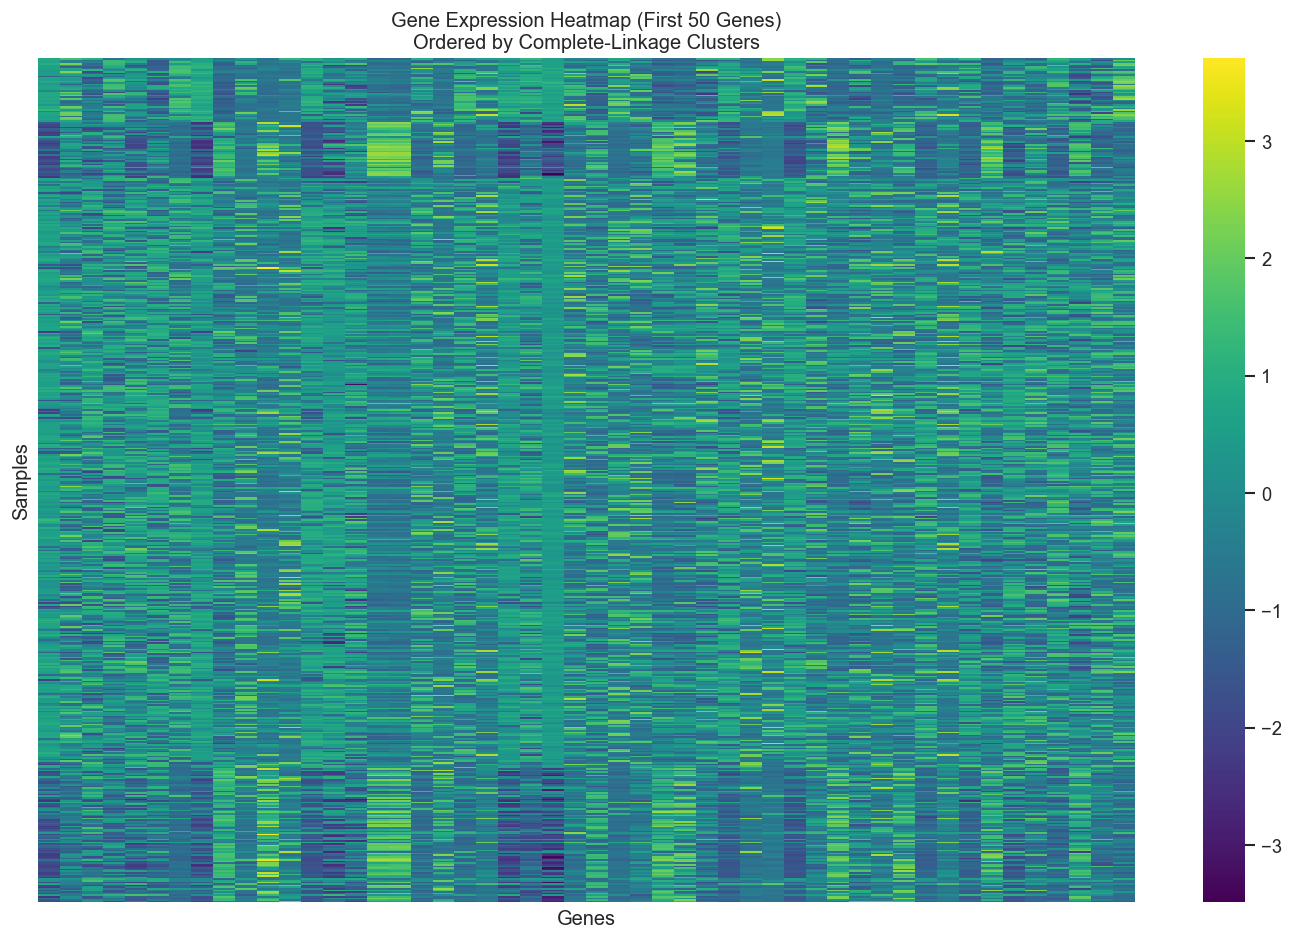

In [15]:
# Use complete-linkage labels since it performed best

sorted_idx = np.argsort(complete_labels)

X_sorted = X_original[sorted_idx]

heatmap_data = X_sorted[:, :50]

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    cmap='viridis',
    cbar=True,
    xticklabels=False,
    yticklabels=False
)

plt.title('Gene Expression Heatmap (First 50 Genes)\nOrdered by Complete-Linkage Clusters')

plt.xlabel('Genes')
plt.ylabel('Samples')

plt.tight_layout()
plt.show()

---
## 8. Comparison of Linkage Methods

Hierarchical clustering was evaluated using single, complete, and average linkage.

Single linkage produced one very large cluster and several singleton clusters, a common chaining effect that makes interpretation difficult.

Average linkage also produced highly unbalanced clusters and showed almost no agreement with the K-Means solution.

Complete linkage generated the most balanced cluster structure and achieved the highest Adjusted Rand Index (ARI) when compared with K-Means.

Therefore, complete linkage appears to provide the most interpretable clustering structure for this dataset and is the preferred hierarchical clustering method among those evaluated.

---
## 9. Summary

| Property | Value |
|-----------|-----------|
| Input matrix | PCA-reduced BC-TCGA tumor data |
| Samples | 529 |
| Features | 24 principal components |
| Linkage methods evaluated | Single, Complete, Average |
| Clusters requested | 4 |
| Best linkage method | Complete |
| Complete-linkage ARI | 0.1903 |
| Heatmap generated | Yes |

### Key Takeaways

1. Hierarchical clustering was successfully performed on the PCA-reduced breast cancer expression dataset.

2. Single linkage suffered from the chaining effect and produced one dominant cluster.

3. Average linkage produced highly unbalanced clusters and showed little agreement with K-Means.

4. Complete linkage generated the most interpretable clustering structure and achieved the highest agreement with K-Means (ARI = 0.1903).

5. The heatmap revealed substantial variation in gene expression across samples, highlighting the biological complexity of the dataset.

6. While hierarchical clustering identified structure in the data, agreement with K-Means remained modest, suggesting that multiple clustering solutions may be plausible for these tumor samples.

In [17]:
pd.DataFrame({
    'SampleID': sample_ids,
    'Cluster': complete_labels
}).to_csv(DATA_DIR / 'hierarchical_clusters.csv', index=False)

print("Saved hierarchical_clusters.csv")

Saved hierarchical_clusters.csv
